# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [24]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    branch = input("GitHub 브랜치명 (기본: jinhyuk): ").strip() or "jinhyuk"
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--branch", branch, clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")
        subprocess.run(["git", "fetch", "origin", branch], cwd=repo_dir, check=True)
        subprocess.run(["git", "checkout", branch], cwd=repo_dir, check=True)
        subprocess.run(["git", "pull", "--ff-only", "origin", branch], cwd=repo_dir, check=True)

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")


GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): https://github.com/LJH098/krafton-gpt-lab
GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ··········
GitHub 브랜치명 (기본: main): jinhyuk
이미 clone된 저장소를 사용합니다: /content/krafton-gpt-lab
Repo: /content/krafton-gpt-lab


In [ ]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [ ]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: /content/krafton-gpt-lab/data/ratings_train.txt
이미 존재합니다: /content/krafton-gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /content/krafton-gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /content/krafton-gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /content/krafton-gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /content/krafton-gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /content/krafton-gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /content/krafton-gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /content/krafton-gpt-lab/data/nsmc_lm_val.txt


In [ ]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [ ]:
run_pytest("tests/test_bpe.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.03s ===============================


선택한 테스트를 통과했습니다.


0

In [ ]:
# BPE 구현 후 data/ 폴더의 tokenizer를 load합니다.
# tokenizer JSON은 repo의 data/bpe_tokenizer_vocab3000.json에 저장/로드합니다.
try:
    from bpe import BPETokenizer

    tokenizer_path = repo_dir / "data" / "bpe_tokenizer_vocab3000.json"
    tokenizer_save_path = tokenizer_path

    tokenizer = BPETokenizer(vocab_size=3000)
    if tokenizer_path.exists():
        tokenizer.load(tokenizer_path)
        print("BPE tokenizer loaded:", tokenizer_path)
    else:
        tokenizer_save_path.parent.mkdir(parents=True, exist_ok=True)
        print("BPE tokenizer not found. Training and saving:", tokenizer_save_path)
        tokenizer.train(corpus)
        tokenizer.save(tokenizer_save_path)

    vocab_size = len(tokenizer.id_to_token)
    print("vocab size:", vocab_size)

    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [ ]:
run_pytest("tests/test_dataset.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 2.18s ===============================


선택한 테스트를 통과했습니다.


0

In [ ]:
try:
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=vocab_size, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NameError:
    print("먼저 Step 1 tokenizer load 셀을 실행하세요.")
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)


torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [ ]:
run_pytest("tests/test_attention.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.74s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [ ]:
run_pytest("tests/test_model.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

============================== 7 passed in 

0

In [ ]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": vocab_size,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NameError:
    print("먼저 Step 1 tokenizer load 셀을 실행하세요.")
except NotImplementedError as e:
    print("Model TODO 미구현:", e)


torch.Size([2, 16, 3000])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [ ]:
run_pytest("tests/test_train.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_train.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== 5 passed in 3.45s ===============================


선택한 테스트를 통과했습니다.


0

In [ ]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": vocab_size,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NameError:
    print("먼저 Step 1 tokenizer load 셀을 실행하세요.")
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)


smoke loss: 8.211518287658691


### Step 5 실제 사전 학습 실행

저장된 BPE tokenizer와 NSMC LM corpus로 작은 GPT를 실제로 학습합니다. 기본 설정은 Colab에서 빠르게 확인하는 용도이며, 시간이 더 있으면 `TRAIN_CHARS`, `NUM_EPOCHS`, 모델 크기를 키우세요.


In [ ]:
# 실제 pretraining용 dataloader/model/optimizer를 준비합니다.
# tokenization 결과는 data/cache에 캐시해서 런타임 재시작 후에도 바로 재사용합니다.
try:
    import hashlib
    import torch
    from dataset import create_dataloader
    from model import GPTModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    # 실험 preset
    # 빠른 확인:  TRAIN_CHARS=100_000,  VAL_CHARS=20_000,  NUM_EPOCHS=3
    # 적당한 학습: TRAIN_CHARS=500_000,  VAL_CHARS=50_000,  NUM_EPOCHS=5
    # 더 제대로:   TRAIN_CHARS=1_500_000, VAL_CHARS=100_000, NUM_EPOCHS=8
    # 오래 학습:   TRAIN_CHARS=len(corpus), VAL_CHARS=len(val_corpus), NUM_EPOCHS=10 이상
    TRAIN_CHARS = 1_500_000
    VAL_CHARS = 100_000
    NUM_EPOCHS = 8

    # 데이터/배치 가설: context가 길수록 문맥은 늘지만 메모리와 시간이 증가합니다.
    CONTEXT_LENGTH = 64
    BATCH_SIZE = 16 if device.type == "cuda" else 4
    TRAIN_STRIDE = CONTEXT_LENGTH
    VAL_STRIDE = CONTEXT_LENGTH
    TRAIN_DROP_LAST = True

    # 모델 크기 가설: emb_dim/layers/heads를 키우면 표현력은 늘지만 과적합과 시간 비용도 증가합니다.
    PRETRAIN_EMB_DIM = 128
    PRETRAIN_N_HEADS = 4
    PRETRAIN_N_LAYERS = 2
    PRETRAIN_DROP_RATE = 0.1
    PRETRAIN_QKV_BIAS = False

    # 최적화 가설: lr/weight_decay는 loss 하강 속도와 일반화에 직접 영향을 줍니다.
    PRETRAIN_LR = 3e-4
    PRETRAIN_WEIGHT_DECAY = 0.1

    cache_dir = repo_dir / "data" / "cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    # Tokenization 결과는 tokenizer와 입력 text 범위가 같으면 동일합니다.
    # context_length, batch_size, lr, model size, epoch는 DataLoader/model만 바꾸므로 cache key에서 제외합니다.
    train_text = corpus[:TRAIN_CHARS]
    val_text = val_corpus[:VAL_CHARS]
    tokenizer_hash = hashlib.sha256(tokenizer_path.read_bytes()).hexdigest()[:12]
    train_text_hash = hashlib.sha256(train_text.encode("utf-8")).hexdigest()[:12]
    val_text_hash = hashlib.sha256(val_text.encode("utf-8")).hexdigest()[:12]

    token_cache_path = cache_dir / (
        f"pretrain_tokens_tok{tokenizer_hash}_"
        f"train{TRAIN_CHARS}_{train_text_hash}_"
        f"val{VAL_CHARS}_{val_text_hash}.pt"
    )

    legacy_cache_paths = sorted(
        cache_dir.glob(
            f"pretrain_tokens_vocab{vocab_size}_ctx*_train{TRAIN_CHARS}_val{VAL_CHARS}.pt"
        )
    )

    if token_cache_path.exists():
        cached = torch.load(token_cache_path, map_location="cpu")
        train_token_ids = cached["train_token_ids"]
        val_token_ids = cached["val_token_ids"]
        print("token cache loaded:", token_cache_path)
    elif legacy_cache_paths:
        legacy_cache_path = legacy_cache_paths[0]
        cached = torch.load(legacy_cache_path, map_location="cpu")
        train_token_ids = cached["train_token_ids"]
        val_token_ids = cached["val_token_ids"]
        cached.update(
            {
                "tokenizer_hash": tokenizer_hash,
                "train_text_hash": train_text_hash,
                "val_text_hash": val_text_hash,
                "cache_key_ignores": [
                    "context_length",
                    "batch_size",
                    "learning_rate",
                    "model_size",
                    "num_epochs",
                ],
            }
        )
        torch.save(cached, token_cache_path)
        print("legacy token cache migrated:", legacy_cache_path)
        print("token cache saved:", token_cache_path)
    else:
        print("token cache not found. Encoding corpus now:", token_cache_path)
        train_token_ids = tokenizer.encode(train_text)
        val_token_ids = tokenizer.encode(val_text)
        torch.save(
            {
                "train_token_ids": train_token_ids,
                "val_token_ids": val_token_ids,
                "vocab_size": vocab_size,
                "tokenizer_hash": tokenizer_hash,
                "train_chars": TRAIN_CHARS,
                "val_chars": VAL_CHARS,
                "train_text_hash": train_text_hash,
                "val_text_hash": val_text_hash,
                "cache_key_ignores": [
                    "context_length",
                    "batch_size",
                    "learning_rate",
                    "model_size",
                    "num_epochs",
                ],
            },
            token_cache_path,
        )
        print("token cache saved:", token_cache_path)

    train_loader = create_dataloader(
        train_token_ids,
        context_length=CONTEXT_LENGTH,
        batch_size=BATCH_SIZE,
        stride=TRAIN_STRIDE,
        shuffle=True,
        drop_last=TRAIN_DROP_LAST,
    )
    val_loader = create_dataloader(
        val_token_ids,
        context_length=CONTEXT_LENGTH,
        batch_size=BATCH_SIZE,
        stride=VAL_STRIDE,
        shuffle=False,
        drop_last=False,
    )

    pretrain_config = {
        "vocab_size": vocab_size,
        "context_length": CONTEXT_LENGTH,
        "emb_dim": PRETRAIN_EMB_DIM,
        "n_heads": PRETRAIN_N_HEADS,
        "n_layers": PRETRAIN_N_LAYERS,
        "drop_rate": PRETRAIN_DROP_RATE,
        "qkv_bias": PRETRAIN_QKV_BIAS,
    }
    model = GPTModel(pretrain_config).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=PRETRAIN_LR,
        weight_decay=PRETRAIN_WEIGHT_DECAY,
    )

    print("config:", pretrain_config)
    print("lr:", PRETRAIN_LR, "weight_decay:", PRETRAIN_WEIGHT_DECAY)
    print("train batches:", len(train_loader), "val batches:", len(val_loader))
    print("train tokens:", len(train_token_ids), "val tokens:", len(val_token_ids))
except NameError:
    print("먼저 데이터 준비 셀과 Step 1 tokenizer load 셀을 실행하세요.")
except NotImplementedError as e:
    print("앞 단계 TODO 미구현:", e)


In [ ]:
def safe_decode(self, ids, skip_special=True):
    byte_values = []

    def expand(token_id):
        token = self.id_to_token[token_id]
        if isinstance(token, str):
            if not skip_special:
                byte_values.extend(token.encode("utf-8"))
        elif isinstance(token, bytes):
            byte_values.extend(token)
        else:
            left, right = token
            expand(left)
            expand(right)

    for token_id in ids:
        expand(token_id)

    return bytes(byte_values).decode("utf-8", errors="replace")

tokenizer.decode = safe_decode.__get__(tokenizer, tokenizer.__class__)
print("patched tokenizer.decode")

In [ ]:
# train_model을 실제로 실행하고 epoch별 train/validation loss를 기록합니다.
try:
    from train import calc_loss_loader, generate_and_print_sample, train_model

    # 평가/샘플링 가설: 자주 평가하면 추적은 쉬워지지만 느려집니다.
    EVAL_ITER = min(20, len(val_loader))
    EVAL_FREQ = max(1, len(train_loader) // 2)
    FINAL_TEST_ITER = min(100, len(val_loader))

    # 생성 품질 확인용 샘플링 설정입니다. 학습 loss에는 영향이 없습니다.
    START_CONTEXT = "이 영화는"
    SAMPLE_MAX_NEW_TOKENS = 80
    SAMPLE_TEMPERATURE = 0.8
    SAMPLE_TOP_K = 40

    train_loss_history = []
    val_loss_history = []
    global_step = 0

    initial_train_loss = calc_loss_loader(train_loader, model, device, EVAL_ITER)
    initial_val_loss = calc_loss_loader(val_loader, model, device, EVAL_ITER)
    print(f"Before training: train loss {initial_train_loss:.3f}, val loss {initial_val_loss:.3f}")

    for epoch in range(NUM_EPOCHS):
        epoch_train_losses = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            device=device,
            num_epochs=epoch + 1,
            eval_freq=EVAL_FREQ,
            eval_iter=EVAL_ITER,
            start_context=START_CONTEXT,
            tokenizer=tokenizer,
            ckpt_freq=None,
            start_epoch=epoch,
            global_step=global_step,
        )
        global_step += len(train_loader)
        train_loss_history.extend(epoch_train_losses)

        val_loss = calc_loss_loader(val_loader, model, device, EVAL_ITER)
        val_loss_history.append(val_loss)
        print(f"Epoch {epoch + 1}: train loss {train_loss_history[-1]:.3f}, val loss {val_loss:.3f}")

    final_test_loss = calc_loss_loader(val_loader, model, device, FINAL_TEST_ITER)
    print(f"Final held-out validation loss ({FINAL_TEST_ITER} batches): {final_test_loss:.3f}")

    print("Final sample:")
    generate_and_print_sample(
        model=model,
        tokenizer=tokenizer,
        device=device,
        start_context=START_CONTEXT,
        max_new_tokens=SAMPLE_MAX_NEW_TOKENS,
        context_size=CONTEXT_LENGTH,
        temperature=SAMPLE_TEMPERATURE,
        top_k=SAMPLE_TOP_K,
    )
except NameError:
    print("먼저 pretraining 준비 셀을 실행하세요.")
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)


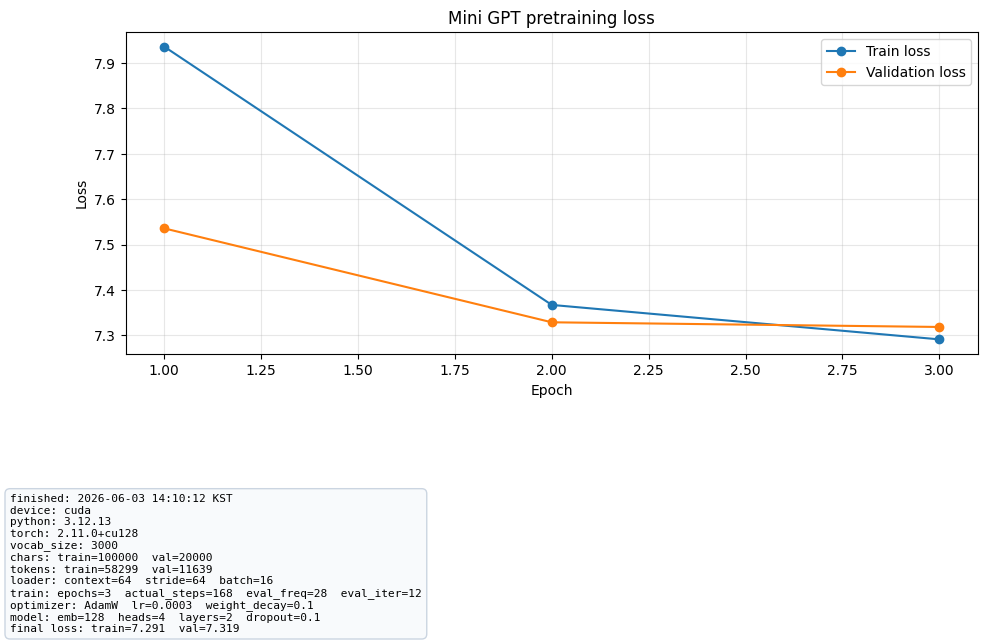

saved loss plot: /content/krafton-gpt-lab/output/training_runs/loss_20260603_133037_steps168.png
train loss history: [7.936, 7.367, 7.291]
val loss history: [7.536, 7.329, 7.319]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 학습 곡선을 그리고, 실험 조건을 그래프 안에 적은 PNG로 저장합니다.
try:
    import matplotlib.pyplot as plt
    from pathlib import Path
    from datetime import datetime, timezone, timedelta
    import platform

    KST = timezone(timedelta(hours=9))

    # repo_dir이 없으면 현재 작업 디렉터리 기준으로 저장
    try:
        result_dir = repo_dir / "output" / "training_runs"
    except NameError:
        result_dir = Path.cwd() / "output" / "training_runs"

    result_dir.mkdir(parents=True, exist_ok=True)

    # run_id가 없으면 현재 시각으로 생성
    try:
        run_id
    except NameError:
        run_id = datetime.now(KST).strftime("%Y%m%d_%H%M%S")

    # global_step이 없으면 epoch 수로 대체
    try:
        global_step
    except NameError:
        global_step = len(train_loss_history)

    plot_path = result_dir / f"loss_{run_id}_steps{global_step}.png"

    epochs = list(range(1, len(train_loss_history) + 1))

    final_train_loss = train_loss_history[-1] if train_loss_history else float("nan")
    final_val_loss = val_loss_history[-1] if val_loss_history else float("nan")

    # 변수 없을 때 안전하게 표시하기 위한 함수
    def safe(name, default="N/A"):
        return globals().get(name, default)

    finished_at = datetime.now(KST)

    cfg = globals().get("pretrain_config", globals().get("config", {}))

    run_conditions = [
        f"finished: {finished_at.strftime('%Y-%m-%d %H:%M:%S KST')}",
        f"device: {safe('device')}",
        f"python: {platform.python_version()}",
        f"torch: {torch.__version__ if 'torch' in globals() else 'N/A'}",
        f"vocab_size: {safe('vocab_size')}",
        f"chars: train={safe('TRAIN_CHARS')}  val={safe('VAL_CHARS')}",
        f"tokens: train={len(train_token_ids) if 'train_token_ids' in globals() else 'N/A'}  "
        f"val={len(val_token_ids) if 'val_token_ids' in globals() else 'N/A'}",
        f"loader: context={safe('CONTEXT_LENGTH')}  "
        f"stride={safe('TRAIN_STRIDE')}  batch={safe('BATCH_SIZE')}",
        f"train: epochs={safe('NUM_EPOCHS')}  actual_steps={global_step}  "
        f"eval_freq={safe('EVAL_FREQ')}  eval_iter={safe('EVAL_ITER')}",
        f"optimizer: AdamW  lr={safe('PRETRAIN_LR')}  "
        f"weight_decay={safe('PRETRAIN_WEIGHT_DECAY')}",
        f"model: emb={cfg.get('emb_dim', 'N/A')}  "
        f"heads={cfg.get('n_heads', 'N/A')}  "
        f"layers={cfg.get('n_layers', 'N/A')}  "
        f"dropout={cfg.get('drop_rate', 'N/A')}",
        f"final loss: train={final_train_loss:.3f}  val={final_val_loss:.3f}",
    ]

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.plot(epochs, train_loss_history, marker="o", label="Train loss")
    ax.plot(epochs, val_loss_history, marker="o", label="Validation loss")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Mini GPT pretraining loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.subplots_adjust(bottom=0.42)

    fig.text(
        0.02,
        0.02,
        "\n".join(run_conditions),
        ha="left",
        va="bottom",
        fontsize=8,
        family="monospace",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "#f8fafc",
            "edgecolor": "#cbd5e1",
        },
    )

    fig.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()

    print("saved loss plot:", plot_path)
    print("train loss history:", [round(x, 3) for x in train_loss_history])
    print("val loss history:", [round(x, 3) for x in val_loss_history])

    # Colab이면 자동 다운로드
    try:
        from google.colab import files
        files.download(str(plot_path))
    except Exception as e:
        print("Colab download skipped:", e)

except NameError:
    print("먼저 실제 pretraining 실행 셀을 실행하세요.")

## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [ ]:
run_pytest("tests/test_finetune.py")

실행 명령: /usr/bin/python3 -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows FAILED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem FAILED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape FAILED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

=================================== FAILURES ===================================
_______ TestMakeSentimentDataset.test_make_sentiment_dataset_splits_rows _______

self = <test_finetune.TestMakeSentimentDataset object at 

1

### Step 6 실제 감성 분류 fine-tuning 실행

사전 학습한 GPT backbone 위에 classification head를 붙여 NSMC 감성 분류를 학습합니다. 아래 설정값을 바꿔가며 가설을 검증하세요.


In [ ]:
# 감성 분류 fine-tuning용 데이터/model/optimizer를 준비합니다.
try:
    import json
    import torch
    from torch.utils.data import DataLoader
    from model import GPTModel
    from finetune import (
        GPTForSequenceClassification,
        ReviewSentimentDataset,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    # 데이터 양 가설: train limit을 늘리면 일반화가 좋아질 수 있지만 시간이 늘어납니다.
    SENTIMENT_TRAIN_LIMIT = 20_000
    SENTIMENT_VAL_LIMIT = 5_000
    SENTIMENT_TEST_LIMIT = 5_000

    # 길이 가설: 긴 리뷰를 더 보게 하면 정보는 늘지만 position/context 비용이 커집니다.
    AUTO_MAX_LENGTH = True
    SENTIMENT_MAX_LENGTH = 128
    SENTIMENT_MAX_LENGTH_CAP = 128

    # 모델/학습 가설
    FINETUNE_BATCH_SIZE = 16 if device.type == "cuda" else 4
    FINETUNE_NUM_EPOCHS = 3
    FINETUNE_LR = 1e-4
    FINETUNE_WEIGHT_DECAY = 0.01
    CLASSIFIER_DROP_RATE = 0.1
    FREEZE_BACKBONE = False

    def read_jsonl(path, limit=None):
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))
                if limit is not None and len(rows) >= limit:
                    break
        return rows

    sentiment_train_path = repo_dir / "data" / "nsmc_sentiment_train.jsonl"
    sentiment_val_path = repo_dir / "data" / "nsmc_sentiment_val.jsonl"
    sentiment_test_path = repo_dir / "data" / "nsmc_sentiment_test.jsonl"

    sentiment_train_data = read_jsonl(sentiment_train_path, SENTIMENT_TRAIN_LIMIT)
    sentiment_val_data = read_jsonl(sentiment_val_path, SENTIMENT_VAL_LIMIT)
    sentiment_test_data = read_jsonl(sentiment_test_path, SENTIMENT_TEST_LIMIT)

    if "pretrain_config" in globals():
        finetune_config = dict(pretrain_config)
    else:
        finetune_config = {
            "vocab_size": vocab_size,
            "context_length": 128,
            "emb_dim": 128,
            "n_heads": 4,
            "n_layers": 2,
            "drop_rate": 0.1,
            "qkv_bias": False,
        }

    model_context_length = finetune_config["context_length"]
    if AUTO_MAX_LENGTH:
        longest_train = max(
            len(tokenizer.encode(row["text"], add_bos_eos=True))
            for row in sentiment_train_data
        )
        sentiment_max_length = min(
            longest_train,
            SENTIMENT_MAX_LENGTH_CAP,
            model_context_length,
        )
    else:
        sentiment_max_length = min(SENTIMENT_MAX_LENGTH, model_context_length)

    train_sentiment_ds = ReviewSentimentDataset(
        sentiment_train_data, tokenizer, max_length=sentiment_max_length
    )
    val_sentiment_ds = ReviewSentimentDataset(
        sentiment_val_data, tokenizer, max_length=sentiment_max_length
    )
    test_sentiment_ds = ReviewSentimentDataset(
        sentiment_test_data, tokenizer, max_length=sentiment_max_length
    )

    train_sentiment_loader = DataLoader(
        train_sentiment_ds, batch_size=FINETUNE_BATCH_SIZE, shuffle=True
    )
    val_sentiment_loader = DataLoader(
        val_sentiment_ds, batch_size=FINETUNE_BATCH_SIZE, shuffle=False
    )
    test_sentiment_loader = DataLoader(
        test_sentiment_ds, batch_size=FINETUNE_BATCH_SIZE, shuffle=False
    )

    if "model" in globals() and getattr(model, "config", None) == finetune_config:
        sentiment_backbone = model
        print("using current pretrained GPT backbone")
    else:
        sentiment_backbone = GPTModel(finetune_config)
        print("using new GPT backbone")

    sentiment_model = GPTForSequenceClassification(
        sentiment_backbone,
        num_labels=2,
        drop_rate=CLASSIFIER_DROP_RATE,
    ).to(device)

    if FREEZE_BACKBONE:
        for param in sentiment_model.gpt.parameters():
            param.requires_grad = False

    sentiment_optimizer = torch.optim.AdamW(
        (param for param in sentiment_model.parameters() if param.requires_grad),
        lr=FINETUNE_LR,
        weight_decay=FINETUNE_WEIGHT_DECAY,
    )

    print("sentiment max_length:", sentiment_max_length)
    print("train/val/test:", len(train_sentiment_ds), len(val_sentiment_ds), len(test_sentiment_ds))
    print("freeze_backbone:", FREEZE_BACKBONE, "lr:", FINETUNE_LR)
except NameError:
    print("먼저 데이터 준비 셀과 Step 1 tokenizer load 셀을 실행하세요.")
except NotImplementedError as e:
    print("감성 분류 TODO 미구현:", e)


In [ ]:
# 감성 분류 fine-tuning을 실행하고 loss/accuracy를 기록합니다.
try:
    from finetune import evaluate_sentiment, train_epoch_sentiment

    sentiment_train_losses = []
    sentiment_val_losses = []
    sentiment_train_accs = []
    sentiment_val_accs = []

    for epoch in range(FINETUNE_NUM_EPOCHS):
        train_loss, train_acc = train_epoch_sentiment(
            sentiment_model, train_sentiment_loader, sentiment_optimizer, device
        )
        val_loss, val_acc = evaluate_sentiment(
            sentiment_model, val_sentiment_loader, device
        )

        sentiment_train_losses.append(train_loss)
        sentiment_val_losses.append(val_loss)
        sentiment_train_accs.append(train_acc)
        sentiment_val_accs.append(val_acc)

        print(
            f"Epoch {epoch + 1}: "
            f"train loss {train_loss:.3f}, train acc {train_acc:.3f}, "
            f"val loss {val_loss:.3f}, val acc {val_acc:.3f}"
        )

    test_loss, test_acc = evaluate_sentiment(sentiment_model, test_sentiment_loader, device)
    print(f"Final test loss {test_loss:.3f}, test acc {test_acc:.3f}")
except NameError:
    print("먼저 감성 분류 fine-tuning 준비 셀을 실행하세요.")


In [ ]:
# 감성 분류 학습 곡선을 그립니다.
try:
    import matplotlib.pyplot as plt

    epochs = list(range(1, len(sentiment_train_losses) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, sentiment_train_losses, marker="o", label="Train loss")
    axes[0].plot(epochs, sentiment_val_losses, marker="o", label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Sentiment fine-tuning loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, sentiment_train_accs, marker="o", label="Train acc")
    axes[1].plot(epochs, sentiment_val_accs, marker="o", label="Val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Sentiment fine-tuning accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
except NameError:
    print("먼저 감성 분류 fine-tuning 실행 셀을 실행하세요.")


## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [ ]:
run_pytest("tests/")

실행 명령: /usr/bin/python3 -m pytest tests/ -v
============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/krafton-gpt-lab
plugins: typeguard-4.5.2, langsmith-0.8.5, anyio-4.13.0
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]
tests/test_bpe.py::TestBPETrain::test_train_increa

1